In [46]:
#import python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

In [47]:
from os import path
#import the data set from google drive
file_path = '/content/drive/MyDrive/colab projects/Netflix Dataset 1.csv'
df = pd.read_csv('/content/drive/MyDrive/colab projects/Netflix Dataset 1.csv')

In [48]:
df.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [49]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Show_Id       7789 non-null   object
 1   Category      7789 non-null   object
 2   Title         7789 non-null   object
 3   Director      5401 non-null   object
 4   Cast          7071 non-null   object
 5   Country       7282 non-null   object
 6   Release_Date  7779 non-null   object
 7   Rating        7782 non-null   object
 8   Duration      7789 non-null   object
 9   Type          7789 non-null   object
 10  Description   7789 non-null   object
dtypes: object(11)
memory usage: 669.5+ KB


In [50]:
df.isnull().sum()

,0
Show_Id,0
Category,0
Title,0
Director,2388
Cast,718
Country,507
Release_Date,10
Rating,7
Duration,0
Type,0


In [51]:
df.duplicated().sum()

np.int64(2)

In [52]:
#missing data
df['Country'] = df['Country'].fillna('unknown')
df.dropna(subset=['Release_Date'], inplace=True)

In [53]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')
df['year']=df['Release_Date'].dt.year

In [54]:
print("\n cleaned Data :")
df.info


 cleaned Data :


<bound method DataFrame.info of      Show_Id Category                                    Title  \
0         s1  TV Show                                       3%   
1         s2    Movie                                    07:19   
2         s3    Movie                                    23:59   
3         s4    Movie                                        9   
4         s5    Movie                                       21   
...      ...      ...                                      ...   
7784   s7783    Movie                                     Zozo   
7785   s7784    Movie                                   Zubaan   
7786   s7785    Movie                        Zulu Man in Japan   
7787   s7786  TV Show                    Zumbo's Just Desserts   
7788   s7787    Movie  ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS   

               Director                                               Cast  \
0                   NaN  João Miguel, Bianca Comparato, Michel Gomes, R...   
1     Jorge Michel Grau  Demián Bichir, Héctor Bonilla, Oscar Serrano, ...   
2          Gilbert Chan  Tedd Chan, Stella Chung, Henley Hii, Lawrence ...   
3           Shane Acker  Elijah Wood, John C. Reilly, Jennifer Connelly...   
4        Robert Luketic  Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...   
...                 ...                                                ...   
7784        Josef Fares  Imad Creidi, Antoinette Turk, Elias Gergi, Car...   
7785        Mozez Singh  Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...   
7786                NaN                                            Nasty C   
7787                NaN                         Adriano Zumbo, Rachel Khoo   
7788           Sam Dunn                                                NaN   

                                                Country Release_Date Rating  \
0                                                Brazil   2020-08-14  TV-MA   
1                                                Mexico   2016-12-23  TV-MA   
2                                             Singapore   2018-12-20      R   
3                                         United States   2017-11-16  PG-13   
4                                         United States   2020-01-01  PG-13   
...                                                 ...          ...    ...   
7784  Sweden, Czech Republic, United Kingdom, Denmar...   2020-10-19  TV-MA   
7785                                              India   2019-03-02  TV-14   
7786                                            unknown   2020-09-25  TV-MA   
7787                                          Australia   2020-10-31  TV-PG   
7788              United Kingdom, Canada, United States   2020-03-01  TV-MA   

       Duration                                               Type  \
0     4 Seasons  International TV Shows, TV Dramas, TV Sci-Fi &...   
1        93 min                       Dramas, International Movies   
2        78 min                Horror Movies, International Movies   
3        80 min  Action & Adventure, Independent Movies, Sci-Fi...   
4       123 min                                             Dramas   
...         ...                                                ...   
7784     99 min                       Dramas, International Movies   
7785    111 min     Dramas, International Movies, Music & Musicals   
7786     44 min  Documentaries, International Movies, Music & M...   
7787   1 Season                 International TV Shows, Reality TV   
7788     90 min                    Documentaries, Music & Musicals   

                                            Description    year  
0     In a future where the elite inhabit an island ...  2020.0  
1     After a devastating earthquake hits Mexico Cit...  2016.0  
2     When an army recruit is found dead, his fellow...  2018.0  
3     In a postapocalyptic world, rag-doll robots hi...  2017.0  
4     A brilliant group of students become card-coun...  2020.0  
...                                                 

# **Performing: trend analysis on the Netflix data set**.

---



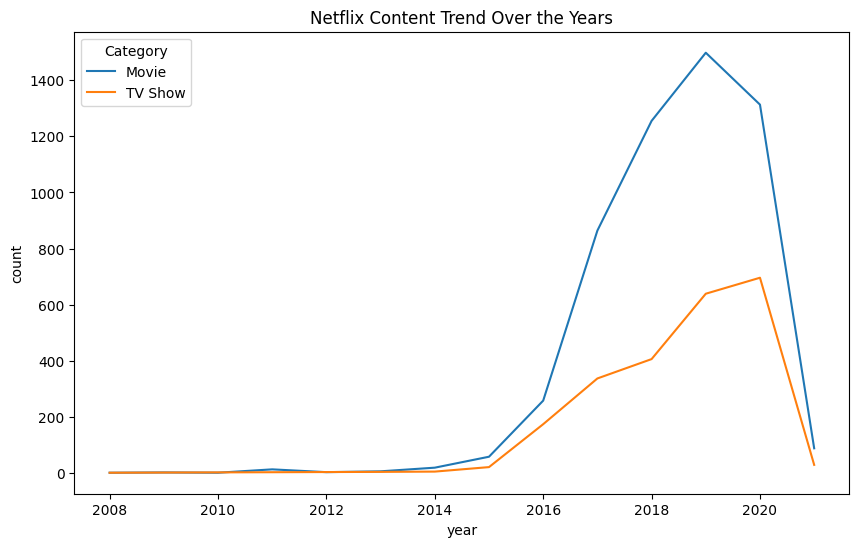

In [55]:
content_trend=df.groupby(['year' , 'Category']).size().reset_index(name='count')
plt.figure(figsize=(10, 6))
sns.lineplot(data=content_trend, x='year', y='count', hue='Category')
plt.title('Netflix Content Trend Over the Years')
plt.show()

# Country wise regional analysis

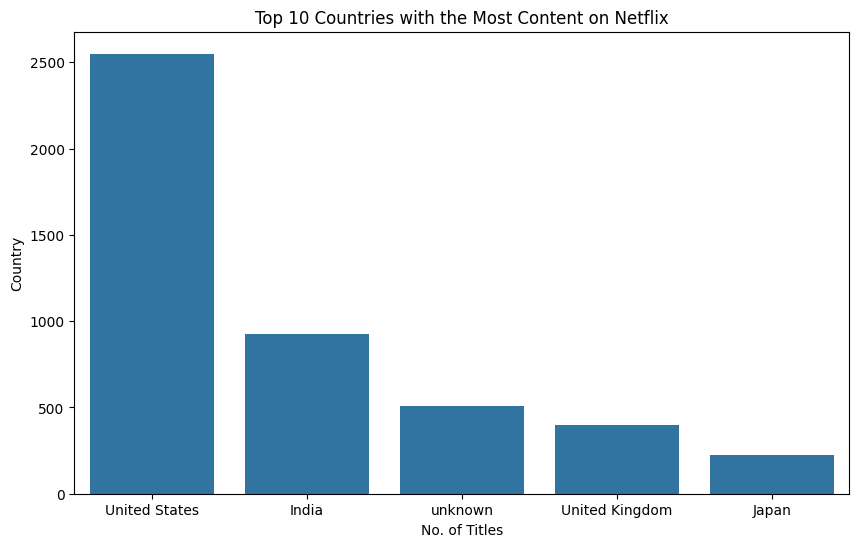

In [56]:
country_count = df['Country'].value_counts().head()
plt.figure(figsize=(10, 6))
sns.barplot(x=country_count.index, y=country_count.values)
plt.title('Top 10 Countries with the Most Content on Netflix')
plt.xlabel('No. of Titles')
plt.ylabel('Country')
plt.show()

# **Text based analysis for discription**

In [57]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

tfidf=TfidfVectorizer(stop_words='english',max_features=1000)
X=tfidf.fit_transform(df['Description'])

kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X)
#view someclusters
print(df.columns)
df[['Title','cluster','Description']].head(10)

Index(['Show_Id', 'Category', 'Title', 'Director', 'Cast', 'Country',
       'Release_Date', 'Rating', 'Duration', 'Type', 'Description', 'year',
       'cluster'],
      dtype='object')


,Title,cluster,Description
0,3%,4,In a future where the elite inhabit an island ...
1,07:19,4,After a devastating earthquake hits Mexico Cit...
2,23:59,4,"When an army recruit is found dead, his fellow..."
3,9,4,"In a postapocalyptic world, rag-doll robots hi..."
4,21,4,A brilliant group of students become card-coun...
5,46,4,A genetics professor experiments with a treatm...
6,122,0,"After an awful accident, a couple admitted to ..."
7,187,1,After one of his high school students attacks ...
8,706,4,"When a doctor goes missing, his psychiatrist w..."
9,1920,4,An architect and his wife move into a castle t...


In [58]:
from collections import Counter
import re

# Function to get most frequent words in a list of texts
def get_most_frequent_words(text_list, num_words=10):
    words = ' '.join(text_list).lower()
    words = re.findall(r'\b\w+\b', words)
    word_counts = Counter(words)
    return word_counts.most_common(num_words)

# Iterate through each cluster and find most frequent words
for cluster_id in sorted(df['cluster'].unique()):
    cluster_descriptions = df[df['cluster'] == cluster_id]['Description'].tolist()
    most_common_words = get_most_frequent_words(cluster_descriptions)
    print(f"Cluster {cluster_id} - Most Frequent Words:")
    for word, count in most_common_words:
        print(f"- {word}: {count}")
    print("-" * 30)

Cluster 0 - Most Frequent Words:
- a: 755
- to: 359
- the: 337
- and: 316
- home: 237
- finds: 234
- of: 232
- in: 230
- his: 208
- her: 183
------------------------------
Cluster 1 - Most Frequent Words:
- a: 688
- and: 499
- the: 480
- to: 436
- friends: 366
- of: 329
- school: 281
- in: 263
- his: 211
- their: 208
------------------------------
Cluster 2 - Most Frequent Words:
- a: 2020
- to: 881
- the: 855
- and: 651
- of: 578
- young: 568
- his: 544
- in: 535
- man: 435
- her: 405
------------------------------
Cluster 3 - Most Frequent Words:
- a: 519
- the: 379
- to: 308
- and: 256
- of: 210
- in: 184
- her: 179
- mother: 167
- his: 152
- s: 128
------------------------------
Cluster 4 - Most Frequent Words:
- a: 6178
- the: 5170
- and: 3898
- to: 3714
- of: 3373
- in: 2702
- his: 1899
- s: 1587
- with: 1271
- on: 1091
------------------------------


In [59]:
fig = px.scatter(df, x='year', y='cluster', color='cluster', title='Netflix Content Clusters Over the Years')
fig.show()

In [60]:
df.to_csv('netflix_cleaned.csv', index=False)

#**conclusion**


---

**Content Trend**: We observed the trend of Netflix content over the years, showing how the number of movies and TV shows added to the platform has changed over time.

**Country Analysis**: We identified the top countries with the most content available on Netflix, giving us insight into the regional distribution of their library.

**Text-Based Clustering**: By analyzing the descriptions of the content, we grouped similar titles into clusters based on their textual content. We also looked at the most frequent words in each cluster to understand the common themes present in those groups.

In conclusion, we have explored the growth of Netflix's content library over the years, its geographical distribution, and the thematic groupings of its content based on descriptions. This provides a foundational understanding of the Netflix catalog from different perspectives.